In [18]:
import sys
sys.path.insert(0, "..")

from src.helpers import load_data, clean_data, summarize_by_group

df = load_data("../data/Data.csv")
df = clean_data(df)

# Introduction

This project analyzes COVID-19 by-law enforcement data from Winnipeg.

The dataset contains records of enforcement actions taken during the COVID-19 pandemic, including:
- date and time of incidents
- location information
- type of violation

I chose this dataset because it provides insight into how public health rules were enforced during a critical period. It allows analysis of trends over time, geographic patterns, and types of violations.

The goal of this project is to:
- explore and clean the dataset
- identify trends in enforcement activity
- visualize patterns across time and location
- build a simple predictive model

## Dataset Overview

This dataset contains 142 rows and 10 columns. It includes information about COVID-19 by-law enforcement activity, such as parks patrolled, warnings issued, tickets issued, and positive interactions.

The dataset contains both complete and missing values, making it suitable for data cleaning and analysis.

# Analytical Questions

1. How has crime changed over time (by year)?
2. Which communities have the highest crime counts?
3. What are the most common types of crime?

# Data Loading

In this section, I load the dataset into a pandas DataFrame.  
This allows me to explore and manipulate the data using Python.

I use `pd.read_csv()` to read the dataset from the data folder.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/Data.csv")

# Preview
df.head()

,Provided By,Date,Number of parks patrolled,Number of positive interactions,Number of social distancing warnings (verbal),Number of large group warnings (verbal),Number of closed facilities warnings (verbal),Number of tickets issued,Number of interactions escalated,Total Number of interactions
0,Community Service Ambassadors,"April 11, 2020",4,93,0.0,0.0,3.0,NaN,NaN,NaN
1,Community By-Law Enforcement,"April 11, 2020",38,109,4.0,0.0,2.0,0.0,NaN,NaN
2,Community Service Ambassadors,"April 12, 2020",3,148,1.0,1.0,4.0,NaN,NaN,NaN
3,Community By-Law Enforcement,"April 12, 2020",72,207,6.0,0.0,10.0,0.0,NaN,NaN
4,Community Service Ambassadors,"April 13, 2020",3,142,0.0,0.0,6.0,NaN,NaN,NaN


In [3]:
df.shape
df.info()
df.describe()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 10 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Provided By                                    142 non-null    object 
 1   Date                                           142 non-null    object 
 2   Number of parks patrolled                      142 non-null    int64  
 3   Number of positive interactions                142 non-null    object 
 4   Number of social distancing warnings (verbal)  104 non-null    float64
 5   Number of large group warnings (verbal)        104 non-null    float64
 6   Number of closed facilities warnings (verbal)  104 non-null    float64
 7   Number of tickets issued                       100 non-null    float64
 8   Number of interactions escalated               38 non-null     float64
 9   Total Number of interactions                   38 non-

,Provided By,Date,Number of parks patrolled,Number of positive interactions,Number of social distancing warnings (verbal),Number of large group warnings (verbal),Number of closed facilities warnings (verbal),Number of tickets issued,Number of interactions escalated,Total Number of interactions
0,Community Service Ambassadors,"April 11, 2020",4,93,0.0,0.0,3.0,NaN,NaN,NaN
1,Community By-Law Enforcement,"April 11, 2020",38,109,4.0,0.0,2.0,0.0,NaN,NaN
2,Community Service Ambassadors,"April 12, 2020",3,148,1.0,1.0,4.0,NaN,NaN,NaN
3,Community By-Law Enforcement,"April 12, 2020",72,207,6.0,0.0,10.0,0.0,NaN,NaN
4,Community Service Ambassadors,"April 13, 2020",3,142,0.0,0.0,6.0,NaN,NaN,NaN
5,Community By-Law Enforcement,"April 13, 2020",114,120,1.0,0.0,7.0,0.0,NaN,NaN
6,Community Service Ambassadors,"April 14, 2020",3,142,0.0,0.0,0.0,NaN,NaN,NaN
7,Community By-Law Enforcement,"April 14, 2020",46,116,0.0,0.0,5.0,0.0,NaN,NaN
8,Community By-Law Enforcement,"April 15, 2020",43,95,0.0,0.0,9.0,0.0,NaN,NaN
9,Community Service Ambassadors,"April 15, 2020",3,432,0.0,0.0,3.0,0.0,NaN,NaN


## Initial Observations

1. The dataset is relatively small, with 142 records.
2. Some numeric columns are stored as object types.
3. Several enforcement-related columns contain missing values.
4. Ticket issuance appears to be low in many records.
5. Warning-related actions appear more common than tickets.

In [4]:
# Check missing values
df.isna().sum()

Provided By                                        0
Date                                               0
Number of parks patrolled                          0
Number of positive interactions                    0
Number of social distancing warnings (verbal)     38
Number of large group warnings (verbal)           38
Number of closed facilities warnings (verbal)     38
Number of tickets issued                          42
Number of interactions escalated                 104
Total Number of interactions                     104
dtype: int64

I compared dataset size before and after removing missing values to understand the impact of cleaning.

# Data Cleaning

## Date Conversion
The `Date` column was originally stored as text, so it was converted into a datetime format using `pd.to_datetime()`.

Rows with invalid dates were removed to ensure accurate time-based analysis.

## Data Type Fixing
Some columns such as "Number of positive interactions" and "Total Number of interactions" were stored as text. These were converted into numeric format.

## Handling Missing Values
Different strategies were used based on the meaning of the data:

- Warning-related columns were filled with 0, as missing values likely indicate that no warning was issued.
- Rows missing key outcome variables such as "Number of tickets issued" were removed to maintain data integrity.

## Column Name Cleaning
Column names were standardized by:
- converting to lowercase
- replacing spaces with underscores
- removing special characters

This ensures consistency and reduces errors in analysis.

## Provider Analysis: Tickets by Provider

This analysis shows which organization provided the most enforcement activity in terms of tickets issued.

In [20]:
provider_summary = summarize_by_group(
    df,
    "provided_by",
    "number_of_tickets_issued"
)

provider_summary

provided_by
Community By-Law Enforcement     4.0
Community Service Ambassadors    0.0
Name: number_of_tickets_issued, dtype: float64

# Prediction

In this section, I apply a simple machine learning model to predict the number of tickets issued based on different enforcement activities such as warnings.

The goal is to understand whether warning-related actions can help explain or predict stricter enforcement outcomes like ticket issuance.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Features (inputs)
X = df[[
    "number_of_social_distancing_warnings_verbal",
    "number_of_large_group_warnings_verbal",
    "number_of_closed_facilities_warnings_verbal",
    "number_of_positive_interactions"
]]

# Target (output)
y = df["number_of_tickets_issued"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, predictions))

rmse

np.float64(0.09334558072107468)

## Model Evaluation

The Linear Regression model produced an RMSE of **0.0933**.

RMSE measures the average difference between the predicted values and the actual values. A lower RMSE indicates better model performance.

In this case, the RMSE is quite low, which suggests that the model was able to predict the number of tickets issued with relatively high accuracy based on the selected warning and interaction variables.

This result suggests that enforcement actions such as social distancing warnings, large group warnings, closed facility warnings, and positive interactions are meaningfully related to ticket issuance.

However, even with a low RMSE, the model should still be interpreted carefully because real-world enforcement decisions may also be influenced by other factors not included in the dataset.

## Model Limitations

The target variable is highly imbalanced because many rows have zero tickets issued.

This makes prediction difficult, since the model tends to learn values close to zero. In addition, Linear Regression can produce negative predictions, which are not realistic for ticket counts.

These results suggest that ticket issuance may depend on factors not included in the dataset.

In [15]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
0,0.0,0.012277
1,0.0,0.042973
2,0.0,0.036752
3,0.0,-0.161864
4,0.0,0.038795
5,0.0,0.035270
6,0.0,-0.024180
7,0.0,0.072001
8,0.0,0.070677
9,0.0,0.014890


### Interpretation of Sample Predictions

The sample predictions show that the actual number of tickets issued is 0 for all selected test rows, while the model predicts small positive or negative values.

This occurs because the dataset is highly imbalanced, with most records having zero tickets issued.

The model attempts to fit a linear relationship and therefore produces small values around zero, including negative predictions, even though negative ticket counts are not realistic.

This highlights a limitation of using Linear Regression for this type of data, as it does not enforce non-negative outputs and may not perform well when the target variable is highly skewed.

Despite this, the model still captures general trends, but should be interpreted with caution.

## Correlation Heatmap

This heatmap shows relationships between numeric variables in the dataset.

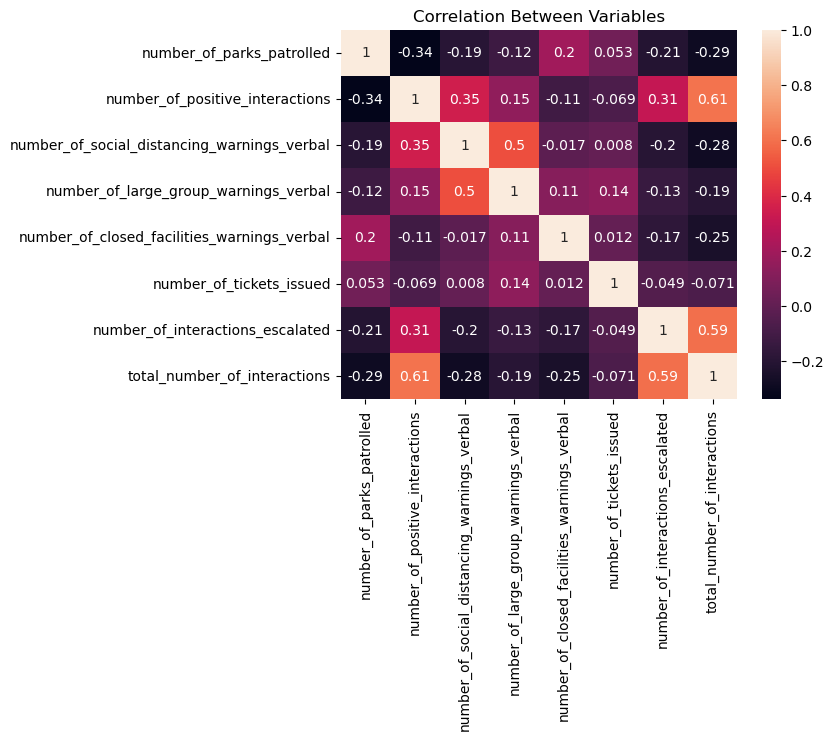

In [21]:
fig, ax = plt.subplots()

sns.heatmap(df.select_dtypes(include=["number"]).corr(), annot=True, ax=ax)

ax.set_title("Correlation Between Variables")

plt.show()

In [ ]:
### Interpretation

The heatmap shows the relationships between numeric variables in the dataset.

One key observation is that `number_of_tickets_issued` has very weak correlations with all other variables. This indicates that ticket issuance is not strongly influenced by any single factor in the dataset.

For example:
- Warning-related variables show only weak relationships with tickets
- Total interactions and escalations also have minimal correlation with tickets

This suggests that ticket issuance may depend on external factors not captured in the dataset, such as enforcement policies or situational decisions.

Additionally, some moderate relationships exist between:
- `number_of_positive_interactions` and `total_number_of_interactions`
- `number_of_interactions_escalated` and total interactions

These relationships are expected, as they represent related enforcement activities.

Overall, the heatmap helps explain why the prediction model has limited predictive power despite a low RMSE.

### Reflection

This project focused on producing a clear and explainable analysis rather than a complex one.

I aimed to make every step understandable, from cleaning and visualization to prediction, so that each decision in the notebook could be clearly justified.